<a href="https://colab.research.google.com/github/Saiful-2/forest-cover-classification/blob/main/notebooks/7_forest_feature_importance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Feature Importance Analysis for Forest Cover Type Classification**
## STEP 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

## STEP 2: Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/Saiful-2/datasets/main/forest_cleaned_dataset.csv"
df = pd.read_csv(url)
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type,Soil_Sum
0,3351,206,27,726,124,3813,192,252,180,2271,...,0,0,0,0,0,1,0,0,1,1
1,2732,129,7,212,1,1082,231,236,137,912,...,0,0,0,0,0,0,0,0,2,1
2,2572,24,9,201,25,957,216,222,142,2191,...,0,0,0,0,0,0,0,0,2,1
3,2824,69,13,417,39,3223,233,214,110,6478,...,0,0,0,0,0,0,0,0,2,1
4,2529,84,5,120,9,1092,227,231,139,4983,...,0,0,0,0,0,0,0,0,2,1


## STEP 3: Prepare Data

In [3]:
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## STEP 4: Train Model
(Feature importance works best with tree-based models)

👉 Random Forest

In [4]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

## STEP 5: Extract Feature Importance

In [5]:
importances = model.feature_importances_

feature_names = X.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feat_imp = feat_imp.sort_values(by='Importance', ascending=False)
feat_imp.head()

,Feature,Importance
0,Elevation,0.242335
5,Horizontal_Distance_To_Roadways,0.098729
9,Horizontal_Distance_To_Fire_Points,0.090817
3,Horizontal_Distance_To_Hydrology,0.062543
4,Vertical_Distance_To_Hydrology,0.060542


## STEP 6: Visualize Feature Importance

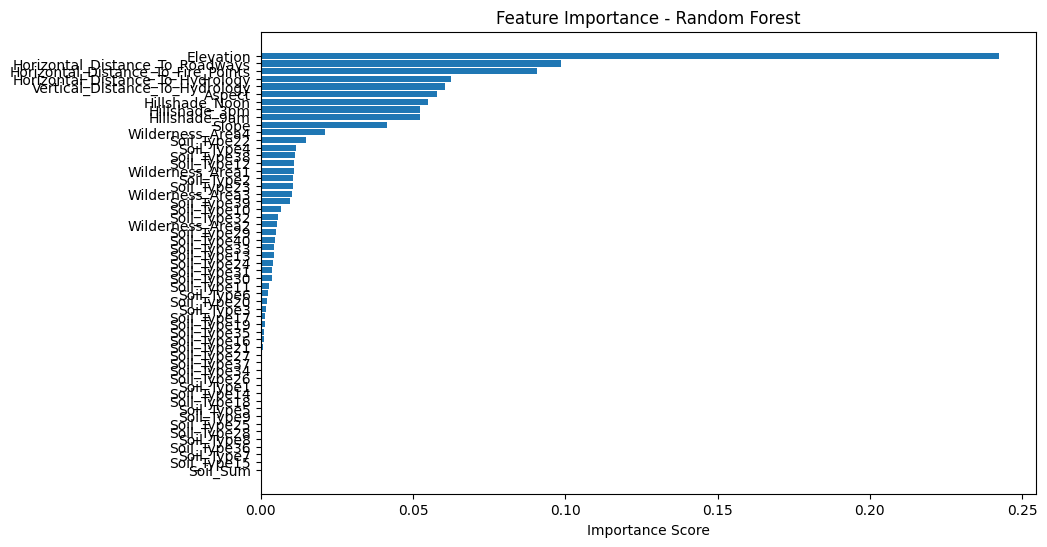

In [6]:
plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

## STEP 7: Top Features Only

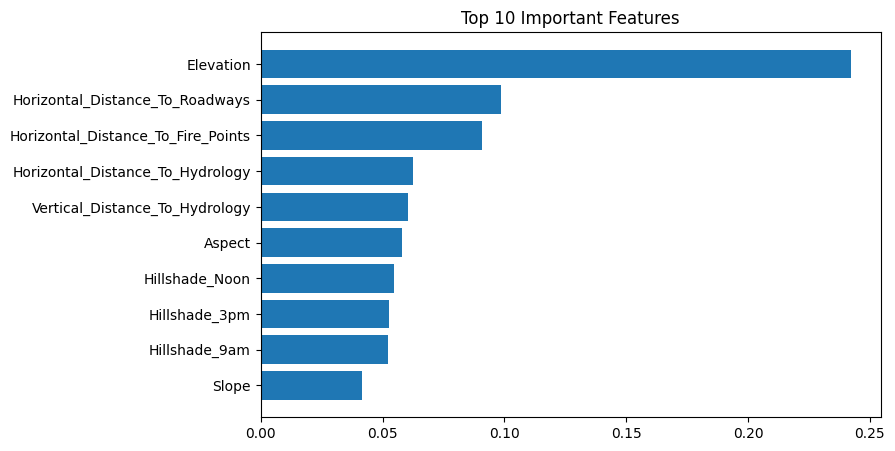

In [7]:
top_features = feat_imp.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

## STEP 8: INSIGHTS
### 🌲 Forest Feature Importance – Key Insights (Brief)
1. Elevation is the most dominant feature, having the highest impact on predicting forest cover type.

2. Distance-based features (especially distance to water and fire points) play a significant role in classification.

3. Hillshade variables (morning, noon, evening) contribute meaningfully, reflecting sunlight influence on vegetation.

4. Most soil type features have low importance individually, indicating sparse influence.

5. A small number of features drive most of the model’s performance (feature importance is highly concentrated).